Testing out different analysis approaches

---

First, lets load in our `NWB` file and unpack it. 

Note that we are not using Pynapple simply because it does not support unpackaging variables stowed away by suite2p

There are some modifications that would need to be made to the `NWB` file to support `Pynapple`, including conversion of our indices or time points to tsGroup

In [1]:
import os; path_added = os.path.split(os.path.split(os.getcwd())[0])[0]; os.chdir(path_added); print("Added path:",path_added)
import nwbfun
import plotters
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# more packages
import seaborn as sea
import pandas as pd
import matplotlib.gridspec as gridspec
from s2pfuns import baseline_corrected_F

import rootfun as rf # we can import this if our cwd is local
root = rf.dropbox_root(dropbox_folder='timspellman')
nwbpath = os.path.join(root,r"timspellman\Python\John\PySpell\code\Projects\Test Data\t284_SEDS2_L5.nwb")

stat, ops, F, Fneu, spks, iscell, probcell, redcell, probredcell = nwbfun.suite2p_nwb().read_nwb(fpath=nwbpath);
behdict = nwbfun.unwrap().spellmanBeh(nwbpath=nwbpath);
time_around=[10,10] # time around event marker for PETH

# spellman et al., 2021: estimated spike events normalized across the session
spkz = stats.zscore(spks, axis=1)

Added path: c:\Users\johnj\SpellmanLab Dropbox\timspellman\Python\John\PySpell\code


Data exploration with `peth`

`peth` was designed specifically for Spellman lab code. So this inherently requires that you used Tims code to convert your behavioral data to `.mat` files. Once you have done that

Above, we unpacked our suite2p results and behavioral data from the `nwb` file! You could create custom code, or you could use the `peth` function from the `plotters` module

VALIDATION:
    `peth` was validated

In [ ]:
# this should be under a different function name
peth = plotters.seds_peth(neural_data = spks[iscell,:], fs=ops['fs'], behdata=behdict, time_around=[10,10]);

trialStartTimes detected
rewardTimes detected
stimOnTimes detected
stimOffTimes detected
lickTimesL detected
lickTimesR detected
rewardTimesIdxTrials detected


Here are some of our options to explore:

`peth['trialStartTimes']`: neural data assigned above ^^ centered around trial onset times to the amount of time points as assigned above ^^

...

`peth['stimOffTimessetID_1_incorrect_irrelRightRelRight']`: centered data around stimulus offset, on set shift ID 1, from incorrect trials, when irrelevant stimulus was on the right and relevant stimulus was also on the right

The follow code displays every available data combination


TODO: Add code that reads the @Sources2D objects from MATLAB if needed. This is low priority. Keep working on analysis. And rewrite NWB

TODO: Examine tensortools

Text(0.5, 0, 'Time Around stim-onset')

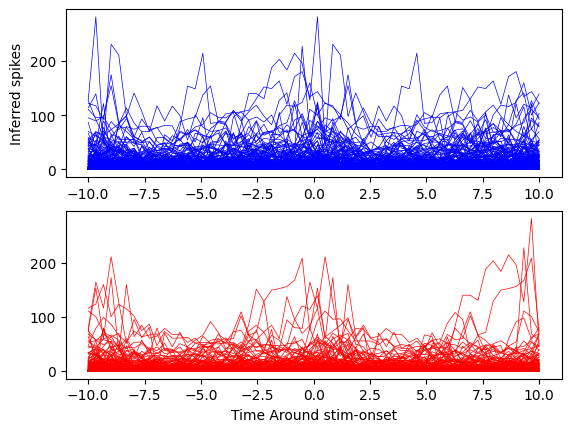

In [ ]:
# identify correct trial and incorrect trial (motivational) reward times
#trial_times = np.concatenate(([behdict['trialStartTimes'][0]], [behdict['trialEndTimes'][0][0:-1]]),axis=0).T
trial_times = np.concatenate(([behdict['trialStartTimes'][0]], [behdict['trialEndTimes'][0]]),axis=0).T
trialRewardCorrectTimes = []; trialRewardIncorrectTimes = []; trialRewardIdx = []
for triali, trialtimes in enumerate(trial_times):
    trial_found = 0
    for rewti in behdict['rewardTimes'][0]:
        if rewti > trialtimes[0] and rewti <= trialtimes[1] and behdict['trialCorrect'][0][triali]==1: # if reward time falls in between trial
            trialRewardCorrectTimes.append(rewti)
            trial_found = 1
        elif rewti > trialtimes[0] and rewti <= trialtimes[1] and behdict['trialCorrect'][0][triali]==0:
            trialRewardIncorrectTimes.append(rewti)
            trial_found = 1
    trialRewardIdx.append(trial_found)
trialRewardCorrectTimes = np.array(trialRewardCorrectTimes)
trialRewardIncorrectTimes = np.array(trialRewardIncorrectTimes)
trialRewardIdx = np.array(trialRewardIdx)


# convert your frametimes, treating your first frameTime as recording start
start_time = behdict['frameTimes'][0][0]; 
end_time   = behdict['frameTimes'][0][-1]; 

numtimes = behdict['frameTimes'][0].shape[0]
relative_start = 0
relative_end = numtimes/3 # num samples/frame rate/secinmin
timestamps = np.linspace(start=relative_start, stop=relative_end, num=numtimes)

# number of components and number of times are fixed
num_components = peth['stimOnTimestrialCorrect'].shape[1]
num_times      = peth['stimOnTimestrialCorrect'].shape[2]

# using the number of time points and the known `time_around` used in `seds_peth`, we can create an x-axis
x_axis = np.linspace(-time_around[0],time_around[1],num_times)

# number of trials varies with variable
num_trials = peth['stimOnTimestrialCorrect'].shape[0]
num_trials_inc = peth['stimOnTimestrialIncorrect'].shape[0]

# create a figure object to assign our data to
fig, ax = plt.subplots(nrows=2, ncols=1)

# plot
for i in range(num_trials):
    ax[0].plot(x_axis,peth['stimOnTimestrialCorrect'][i,100,:],color='blue',linewidth=0.5)

for i in range(num_trials_inc):
    ax[1].plot(x_axis,peth['stimOnTimestrialIncorrect'][i,100,:],color='red',linewidth=0.5)

ax[0].set_ylabel("Inferred spikes")
ax[1].set_xlabel("Time Around stim-onset")

Lets get generative statistics on our inferred spike count data

Text(0, 0.5, 'Mean Std')

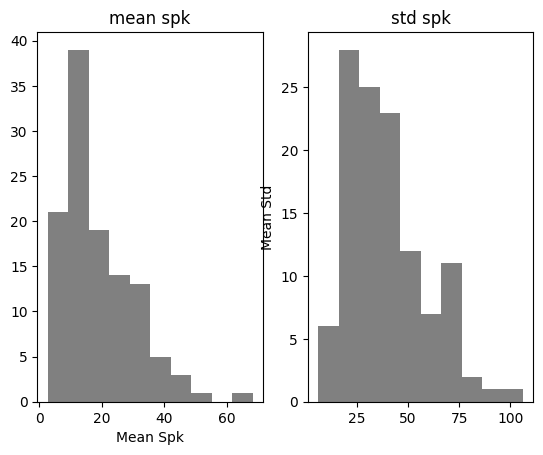

In [ ]:
spkdata = spks[iscell]
avgspk = np.mean(spkdata,axis=1)
stdspk = np.std(spkdata,axis=1)

fig, ax = plt.subplots(nrows=1,ncols=2)
ax[0].hist(avgspk,color='gray'); ax[0].set_title('mean spk'); ax[0].set_xlabel("Mean Spk")
ax[1].hist(stdspk,color='gray'); ax[1].set_title('std spk'); ax[1].set_ylabel("Mean Std")

Let see some general statistics on calcium activity

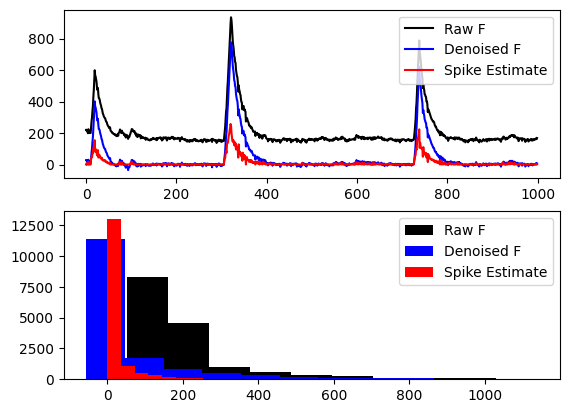

In [ ]:
# baseline corrected F
from s2pfuns import baseline_corrected_F
Fc = baseline_corrected_F(F=F, ops=ops, Fneu=Fneu)

fig, ax = plt.subplots(nrows=2,ncols=1)

ax[0].plot(F[0,0:1000],color='black',label='Raw F')
ax[0].plot(Fc[0,0:1000],color='blue',label='Denoised F')
ax[0].plot(spks[0,0:1000],color='red',label='Spike Estimate')
ax[0].legend(loc='upper right')

ax[1].hist(F[0,:],color='black',label='Raw F')
ax[1].hist(Fc[0,:],color='blue',label='Denoised F')
ax[1].hist(spks[0,:],color='red',label='Spike Estimate')
ax[1].legend(loc='upper right')

#### Heatmaps

It is fun to time lock activity. But it also really informative

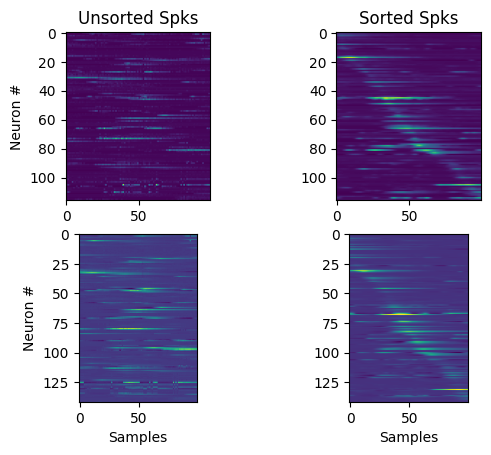

In [ ]:
from plotters import sort_activity_by_xmax
from scipy import stats

fig, ax = plt.subplots(nrows=2,ncols=2)
spkz = stats.zscore(spkdata,axis=1) #zscore over time

# sort by peak activity
spkz_epoch = spkz[:,0:100]

# sorted data
sorted_data_spks, sort_x_idx = sort_activity_by_xmax(neural_data=spkz_epoch)

ax[0,0].imshow(spkz_epoch); ax[0,0].set_ylabel("Neuron #"); ax[0,0].set_title("Unsorted Spks")
ax[0,1].imshow(sorted_data_spks); ax[0,1].set_title("Sorted Spks")

# now do Fc
sorted_data_fc, sort_x_idx = sort_activity_by_xmax(neural_data=Fc[:,0:100])

ax[1,0].imshow(Fc[:,0:100]); ax[1,0].set_xlabel("Samples"); ax[1,0].set_ylabel("Neuron #"); #ax[1,0].set_title("Unsorted Fc")
ax[1,1].imshow(sorted_data_fc); ax[1,1].set_xlabel("Samples"); #ax[1,1].set_title("Sorted Fc")


Using `peth`, lets explore some heatmaps

In [ ]:
correct_choice   = peth['stimOffTimestrialCorrect']
incorrect_choice = peth['stimOffTimestrialIncorrect']
trialnum = 0

# sorted data
correct_sort, cor_idx = sort_activity_by_xmax(neural_data=correct_choice[trialnum,:,:])
incorrect_sort, _     = sort_activity_by_xmax(neural_data=incorrect_choice[trialnum,:,:])

fig, ax = plt.subplots(nrows=1,ncols=2)
ax[0].imshow(correct_sort); ax[0].set_ylabel("Neuron #"); ax[0].set_title("Correct trial sorted by correct")
ax[1].imshow(incorrect_sort[cor_idx]); ax[1].set_title("Incorrect trial sorted by correct trial")

NameError: name 'peth' is not defined

### How correlated are preferred firing locations?

trialStartTimes detected
rewardTimes detected
stimOnTimes detected
stimOffTimes detected
lickTimesL detected
lickTimesR detected
rewardTimesIdxTrials detected


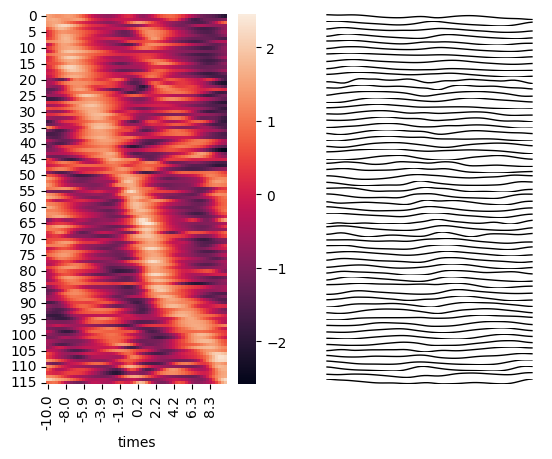

In [ ]:
from scipy import stats
from plotters import sort_activity_by_xmax

# load data
nwbpath = os.path.join(root,r"timspellman\Python\John\PySpell\code\Projects\Test Data\t284_SEDS2_L5.nwb")
stat, ops, F, Fneu, spks, iscell, probcell, redcell, probredcell = nwbfun.suite2p_nwb().read_nwb(fpath=nwbpath)
behdict = nwbfun.unwrap().spellmanBeh(nwbpath=nwbpath)
time_around=[10,10] # time around event marker for PETH

# get baseline F
dfF = baseline_corrected_F(F=F,Fneu=Fneu,ops=ops)

# this should be under a different function name
peth = plotters.seds_peth(neural_data = dfF[iscell,:], fs=ops['fs'], behdata=behdict, time_around=[10,10]);

# take the average over trials
avg_peth = np.mean(peth['rewardTimesIdxTrialstrialCorrect'],axis=0)
peth_z   = stats.zscore(avg_peth,axis=1) #zscore over time
times    = np.linspace(-time_around[0],time_around[1],peth_z.shape[1])

# plot components
sorted_data_spks, sort_x_idx = sort_activity_by_xmax(neural_data=peth_z, smooth_data=True)

# put your data into a dataframe
df  = pd.DataFrame({'times': np.round(times,decimals=1)})
df2 = pd.concat([df, pd.DataFrame(sorted_data_spks.T)],axis=1).set_index('times')
#heatmap = sea.heatmap(df2.transpose())

fig = plt.figure()
ax0 = plt.subplot2grid((2,2), (0,0),rowspan=2)
heatmap = sea.heatmap(df2.transpose(), ax=ax0)

ax = []; counter = 0; every_other = 2; num_comp = int(peth_z.shape[0]/every_other)
for i in range(0, peth_z.shape[0], every_other):
    try:
        plt.subplot2grid((num_comp,2), (counter,1)).plot(times, sorted_data_spks[i], color='k', linewidth=1)
        ax = plt.gca()
        ax.get_yaxis().set_visible(False)

        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        ax.spines['bottom'].set_visible(False)
        ax.spines['left'].set_visible(False)
        ax.get_yaxis().set_ticks([])
        ax.get_xaxis().set_ticks([])

        counter += 1
    except:
        pass

You can generate the figure above using the function below `sorted_heatmap_from_peth`

trialStartTimes detected
rewardTimes detected
stimOnTimes detected
stimOffTimes detected
lickTimesL detected
lickTimesR detected
rewardTimesIdxTrials detected
This function computes the trial averaged mean first, then standardizes or normalizes each traces across time
Rescaling data between 0 and 1


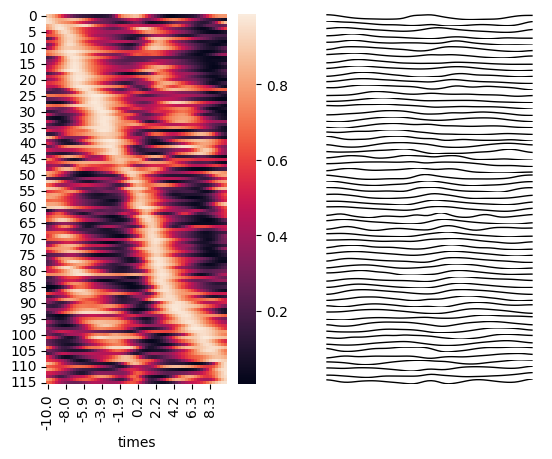

In [ ]:
from plotters import sorted_heatmap_from_peth

# get baseline F
dfF = baseline_corrected_F(F=F,Fneu=Fneu,ops=ops)

# this should be under a different function name
peth = plotters.seds_peth(neural_data = dfF[iscell,:], fs=ops['fs'], behdata=behdict, time_around=[10,10]);

fig = sorted_heatmap_from_peth(peth_input = peth['stimOffTimestrialCorrect'], time_around = time_around, standardize = True, normalize=False)

This function computes the trial averaged mean first, then standardizes or normalizes each traces across time
Rescaling data between 0 and 1


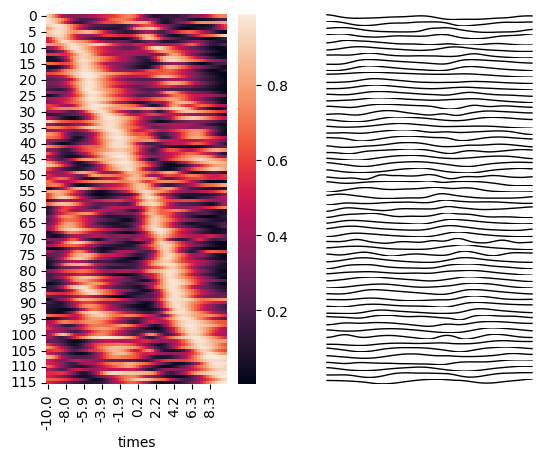

In [ ]:
fig = sorted_heatmap_from_peth(peth_input = peth['stimOnTimestrialCorrect'], time_around = time_around, standardize = True, normalize=False)

This function computes the trial averaged mean first, then standardizes or normalizes each traces across time
Rescaling data between 0 and 1


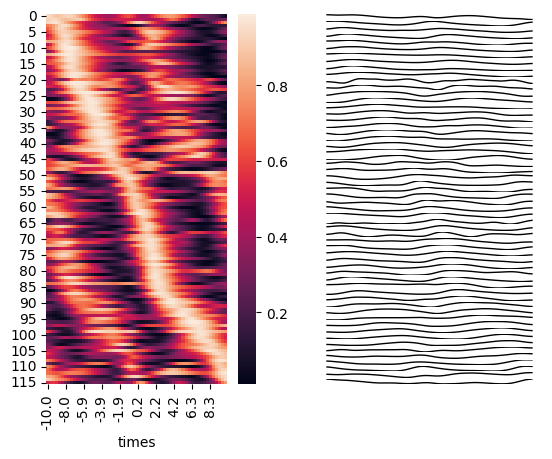

In [ ]:
fig = sorted_heatmap_from_peth(peth_input = peth['rewardTimesIdxTrialstrialCorrect'], time_around = time_around, standardize = True, normalize=False)

### Trial to trial consistency

Conclusion: really hard to draw here. The distribution of trial-to-trial timing consistencies is largely normal, meaning to me that there isn't a whole lot interesting in that small population that are modulated.

Likewise, the heatmaps above are really rhythmic looking. Almost looks like calcium waves. It shouldn't be ignored that the timing is different of those calcium waves


trialStartTimes detected
rewardTimes detected
stimOnTimes detected
stimOffTimes detected
lickTimesL detected
lickTimesR detected
rewardTimesIdxTrials detected


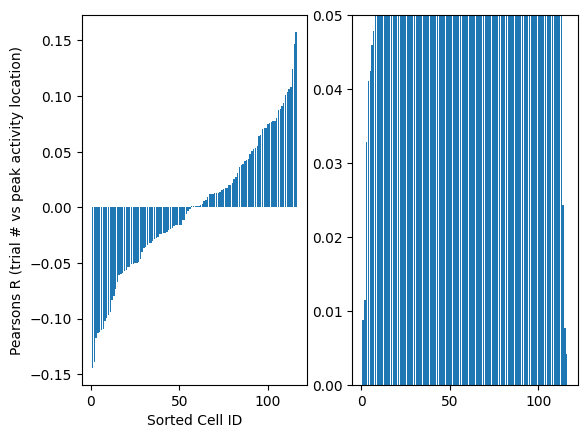

In [ ]:
from scipy import stats

# this should be under a different function name
peth = plotters.seds_peth(neural_data = dfF[iscell,:], fs=ops['fs'], behdata=behdict, time_around=[10,10]);

sorted_idx = []; sorted_data = []
for trial_data in peth['rewardTimesIdxTrialstrialCorrect']:
    # zscored
    peth_z = stats.zscore(trial_data,axis=1)

    # plot components
    sorted_data_spks, sort_x_idx = sort_activity_by_xmax(neural_data=peth_z, smooth_data=True)

    # save
    sorted_idx.append(sort_x_idx); sorted_data.append(sorted_data_spks)

# convert to numpy
sorted_idx       = np.array(sorted_idx)
sorted_data_spks = np.array(sorted_data_spks)

# trial count variable
trial_sequence = np.linspace(1,sorted_idx.shape[0],sorted_idx.shape[0])

r = []; p = []
for i in range(sorted_idx.shape[1]):

    # vector data
    vec_data = sorted_idx[:,i]

    # correlate the first index for all trials
    rout, pout = stats.pearsonr(trial_sequence,vec_data)

    r.append(rout); p.append(pout)
r    = np.array(r); p = np.array(p)
rloc = np.argsort(r) # index of correlation when sorted
ploc = np.argsort(p)

fig, ax = plt.subplots(nrows=1, ncols=2)

ax[0].bar(x=np.linspace(1,r.shape[0],r.shape[0]),height=np.sort(r))
ax[0].set_xlabel("Sorted Cell ID")
ax[0].set_ylabel("Pearsons R (trial # vs peak activity location)")

ax[1].bar(x=np.linspace(1,r.shape[0],r.shape[0]),height=p[np.argsort(r)])
ax[1].set_ylim([0.0,0.05])

sig_cor = np.where(p[np.argsort(r)] < 0.05)
sig_mod_units = np.argsort(r)[sig_cor]

Following this up with some unit exploration

In [ ]:
sig_mod_units

array([  5,  65,  93,  33,  63,  45,  90,  74,   0, 109], dtype=int64)

Text(0.5, 0, 'Time around reward from correct trials')

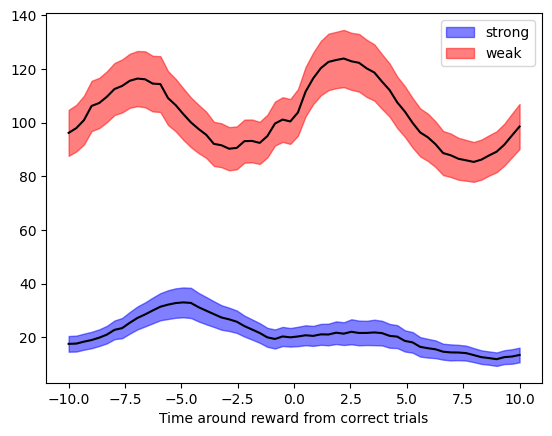

In [ ]:
# get example strong and weakly modulated unit
strong_pos_mod = dfF[iscell][109]
weak_pos_mod   = dfF[iscell][65]

peth_dfF_strong = peth['rewardTimesIdxTrialstrialCorrect'][:,109,:]
peth_dfF_weak   = peth['rewardTimesIdxTrialstrialCorrect'][:,65,:]

# plot data as mean
from scipy.stats import sem

# times (x-axis) variable
times = np.linspace(-time_around[0],time_around[1],peth_dfF_strong.shape[1])

# take the average over trials
avg_peth_strong  = np.mean(peth_dfF_strong, axis=0)
avg_peth_weak    = np.mean(peth_dfF_weak, axis=0)

# take sem over trials
sem_peth_strong = sem(peth_dfF_strong, axis=0)
sem_peth_weak   = sem(peth_dfF_weak,   axis=0)

# make your figure
plt.plot(times, avg_peth_strong,   'k-')
plt.plot(times, avg_peth_weak, 'k-')

plt.fill_between(times, avg_peth_strong - sem_peth_strong, avg_peth_strong + sem_peth_strong, color='b', alpha = 0.5, label='strong')
plt.fill_between(times, avg_peth_weak - sem_peth_weak, avg_peth_weak + sem_peth_weak, color='r', alpha = 0.5, label='weak')

plt.legend()

plt.xlabel("Time around reward from correct trials")

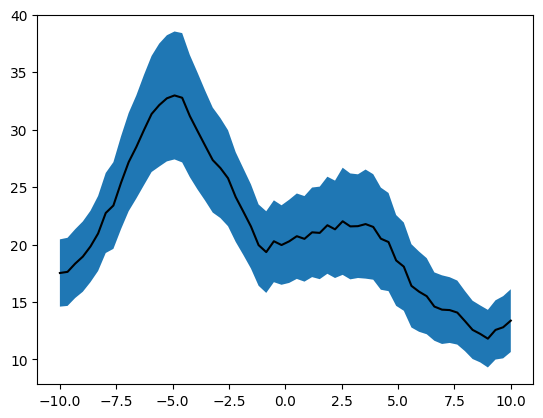

In [ ]:
from plotters import shadedErrorBar

fig = shadedErrorBar(x_data = times, y_mean=avg_peth_strong, y_error=sem_peth_strong)

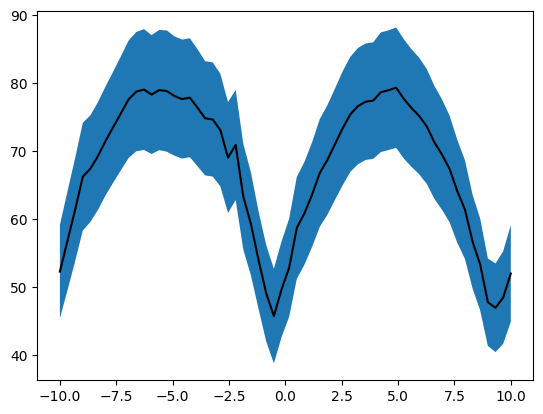

In [ ]:
# take the average over trials
avg_peth_strong  = np.mean(peth['rewardTimesIdxTrialstrialCorrect'][:,0,:], axis=0)

# take sem over trials
sem_peth_strong = sem(peth['rewardTimesIdxTrialstrialCorrect'][:,0,:], axis=0)

fig = shadedErrorBar(x_data = times, y_mean=avg_peth_strong, y_error=sem_peth_strong)

### Cross correlation between activities

What we will do is smooth our dfF, then zscore, then find 1std above mean

Binarize using 1std


So I'm working on creating a plot where x-axis is time around CA event, and y-axis is the calcium activity

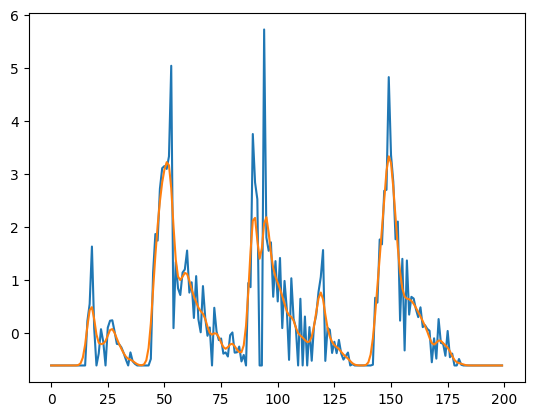

In [ ]:
from scipy.ndimage import gaussian_filter

z_spks   = stats.zscore(spks,axis=1)
smz_spks = gaussian_filter(z_spks,sigma=1.5,axes=1)

plt.plot(z_spks[iscell][1,0:200])
plt.plot(smz_spks[iscell][1,0:200])

In [45]:
spkbool = np.zeros(shape=spkz[iscell].shape); ca_events = []
for celli in range(len(spks[iscell])):
    peaks = np.where(spkz[iscell][celli] > 1)
    spkbool[celli,peaks]=1
    ca_events.append(list(peaks[0]))
spkbool.shape


(116, 15437)

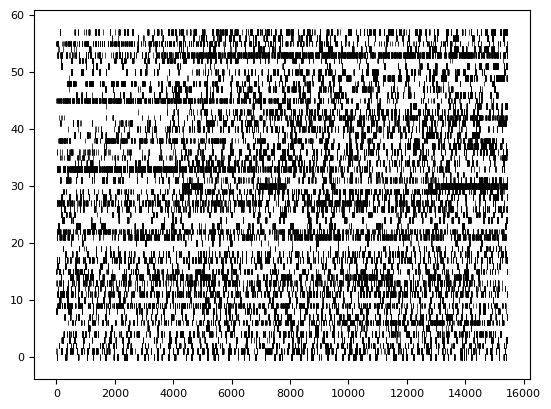

In [53]:
plt.eventplot(ca_events[0::2], color='k',linewidth=0.5)

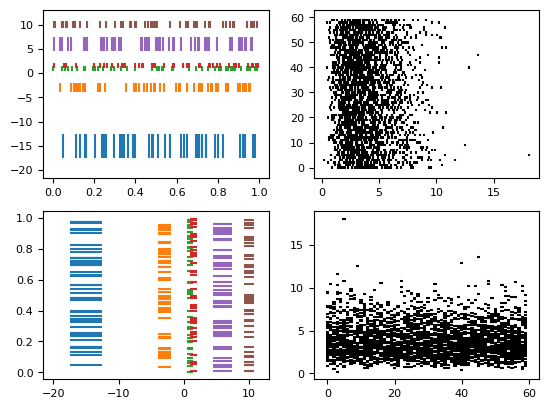

In [32]:

import matplotlib.pyplot as plt
import numpy as np

import matplotlib

matplotlib.rcParams['font.size'] = 8.0

# Fixing random state for reproducibility
np.random.seed(19680801)


# create random data
data1 = np.random.random([6, 50])

# set different colors for each set of positions
colors1 = [f'C{i}' for i in range(6)]

# set different line properties for each set of positions
# note that some overlap
lineoffsets1 = [-15, -3, 1, 1.5, 6, 10]
linelengths1 = [5, 2, 1, 1, 3, 1.5]

fig, axs = plt.subplots(2, 2)

# create a horizontal plot
axs[0, 0].eventplot(data1, colors=colors1, lineoffsets=lineoffsets1,
                    linelengths=linelengths1)

# create a vertical plot
axs[1, 0].eventplot(data1, colors=colors1, lineoffsets=lineoffsets1,
                    linelengths=linelengths1, orientation='vertical')

# create another set of random data.
# the gamma distribution is only used for aesthetic purposes
data2 = np.random.gamma(4, size=[60, 50])

# use individual values for the parameters this time
# these values will be used for all data sets (except lineoffsets2, which
# sets the increment between each data set in this usage)
colors2 = 'black'
lineoffsets2 = 1
linelengths2 = 1

# create a horizontal plot
axs[0, 1].eventplot(data2, colors=colors2, lineoffsets=lineoffsets2,
                    linelengths=linelengths2)


# create a vertical plot
axs[1, 1].eventplot(data2, colors=colors2, lineoffsets=lineoffsets2,
                    linelengths=linelengths2, orientation='vertical')

plt.show()


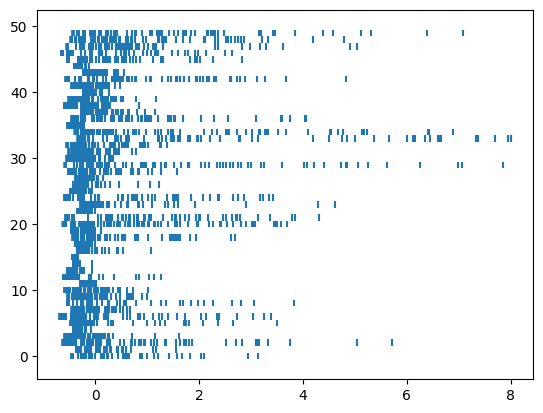

In [ ]:
spkbool = np.zeros(shape=spkz[iscell].shape)
for celli in range(len(spks[iscell])):
    peaks = np.where(spks[iscell][celli] > 1)
    spkbool[celli,peaks]=1
spkbool.shape

plt.eventplot(spkz[0:50,0:100])

In [ ]:
neuralData

array([[0.4359949 , 0.02592623, 0.54966248, 0.43532239, 0.4203678 ,
        0.33033482, 0.20464863, 0.61927097, 0.29965467, 0.26682728,
        0.62113383, 0.52914209, 0.13457995, 0.51357812, 0.18443987,
        0.78533515, 0.85397529, 0.49423684, 0.84656149, 0.07964548,
        0.50524609, 0.0652865 , 0.42812233, 0.09653092, 0.12715997,
        0.59674531, 0.226012  , 0.10694568, 0.22030621, 0.34982629,
        0.46778748, 0.20174323, 0.64040673, 0.48306984, 0.50523672,
        0.38689265, 0.79363745, 0.58000418, 0.1622986 , 0.70075235,
        0.96455108, 0.50000836, 0.88952006, 0.34161365, 0.56714413,
        0.42754596, 0.43674726, 0.77655918, 0.53560417, 0.95374223],
       [0.54420816, 0.08209492, 0.3663424 , 0.8508505 , 0.40627504,
        0.02720237, 0.24717724, 0.06714437, 0.99385201, 0.97058031,
        0.80025835, 0.60181712, 0.76495986, 0.16922545, 0.29302323,
        0.52406688, 0.35662428, 0.04567897, 0.98315345, 0.44135492,
        0.50400044, 0.32354132, 0.25974475, 0.3

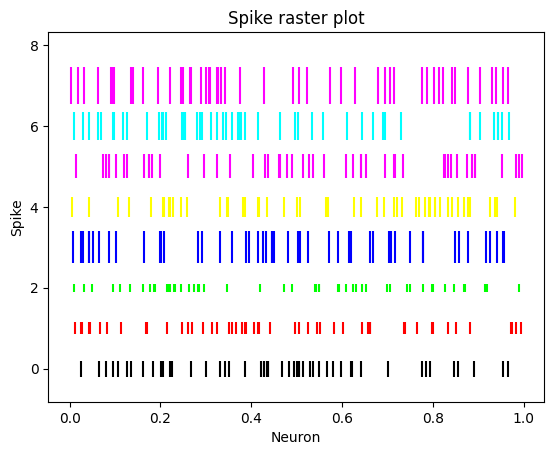

In [ ]:

# Set the random seed for data generation

np.random.seed(2)

 

# Create rows of random data with 50 data points simulating rows of spike trains

neuralData = np.random.random([8, 50])

 

# Set different colors for each neuron

colorCodes = np.array([[0, 0, 0],

                        [1, 0, 0],

                        [0, 1, 0],

                        [0, 0, 1],

                        [1, 1, 0],

                        [1, 0, 1],

                        [0, 1, 1],

                        [1, 0, 1]])

                       

# Set spike colors for each neuron

lineSize = [0.4, 0.3, 0.2, 0.8, 0.5, 0.6, 0.7, 0.9]                                  

        

# Draw a spike raster plot

plt.eventplot(neuralData, color=colorCodes, linelengths = lineSize)     

 

# Provide the title for the spike raster plot

plt.title('Spike raster plot')

 

# Give x axis label for the spike raster plot

plt.xlabel('Neuron')

 

# Give y axis label for the spike raster plot

plt.ylabel('Spike')

 

# Display the spike raster plot

plt.show()

Binarize the data

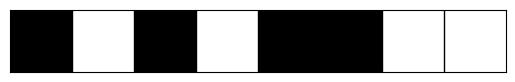

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Replace this with your actual data (a list of 1's and 0's)
my_data = [1, 0, 1, 0, 1, 1, 0, 0]

# Create a 1D NumPy array from your data
x = np.array(my_data)

# Plot the array as an image
plt.imshow(x.reshape(1, -1), extent=[0, len(x), 0, 1], cmap='Greys')
plt.xticks(np.arange(0, len(x), 1), [])
plt.yticks([])
plt.grid(True, axis='x', lw=1, c='black')
plt.tick_params(axis='x', length=0)
plt.show()


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

a = np.array([0, 1, 0, 1, 1, 0, 1, 0])  # Replace with your actual data
af = np.flipud(a)  # Flip upside down to get the right coordinates
args = np.argwhere(af)  # Find the indices where we have non-zero values

plt.figure(figsize=(3, 3))
plt.scatter(args.T[1, :], args.T[0, :], marker="x")
plt.show()


IndexError: index 1 is out of bounds for axis 0 with size 1

<Figure size 300x300 with 0 Axes>